# Train Classifier

This notebook provides tools for training custom cell or vacuole classifiers. It covers labeling data, training models, and selecting the best classifier.

Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for aggregate module

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [2]:
CONFIG_FILE_PATH = "config/config.yml"

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import yaml

from lib.aggregate.cell_classification import CellClassifier
from lib.aggregate.cell_data_utils import split_cell_data
from lib.classify.shared import get_latest_run_dir
from lib.classify.apply import (
    apply_class_thresholds,
    build_master_phenotype_df,
    plot_confidence_distribution,
    summarize_classification,
    display_pngs_in_plots_and_list_models,
    launch_rankline_ui,
    resolve_classifier_model_dill_path,
    show_model_evaluation_pngs,
)
from lib.classify.calibration import calibrate_confidence
from lib.classify.labeling import (
    _render_next_batch,
    build_class_mapping,
    consolidate_manual_classifications,
    filter_existing_from_pools,
    initialize_labeling_state,
    load_checkpoint,
    load_existing_training_data,
    prepare_mask_dataframes,
    resolve_channel_colors,
)
from lib.classify.train import (
    filter_classes,
    load_cellprofiler_data,
    train_classifier_pipeline,
)
from lib.classify.path_utils import get_parquet_config, find_sample_parquet
from lib.shared.configuration_utils import CONFIG_FILE_HEADER
from lib.shared.file_utils import get_filename

_KEYS = ["plate", "well", "tile", "mask_label"]

/home/kmanzer/miniforge3/envs/brieflow_shasta/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [4]:
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)

ROOT_FP = Path(config["all"]["root_fp"])
CLASSIFIER_OUTPUT_DIR = ROOT_FP / "classifier"
CLASSIFIER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Labeling

This section  uses an interactive UI to label objects (ex. cells) to create training data for machine learning models.

**Steps:** **1a)** Configure classification settings → **1b)** Set gating parameters to choose what objects will be displayed in the visualizer → **1c)** Configure display options → Label objects interactively → Save training dataset

### 1a. <font color='red'>SET PARAMETERS</font>: Classification Settings

This section defines the training dataset and classes that will be used for labeling.

**Classification parameters:**
- `TRAINING_DATA_SOURCE`: Source of training data features. Ex. `"phenotype"` or `"merge"`.
- `MODE`: Object to classify. Default: `"cell"`.
- `CLASS_TITLE`: Name of the new column added to the phenotype dataframe.
- `CLASSIFICATION`: List of categories for classification. Categories appear as 1, 2, 3... in output, corresponding to list order.
- `PLATES_TO_CLASSIFY`: List of plates to include in classification.
- `WELLS_TO_CLASSIFY`: List of wells among the specified plates to classify.
  
**If adding to an existing training dataset:**
- `ADD_TRAINING_DATA`: Set to `False` for first-time training, `True` to add to an existing dataset.
- `EXISTING_TRAINING_DATA`: Only set if `ADD_TRAINING_DATA` is `True`. Specify the filepath of the existing training dataset.
- `RELABEL_CLASSIFICATIONS`: Set to `True` to revisit and modify labels from the existing dataset. Previously labeled data will be shown first.

**Data sampling (optional):**
To prevent memory issues when working with many plates/wells, you can subsample the data. Sampling is applied AFTER gating thresholds are calculated, so percentile-based gates remain accurate. These settings apply to both training (labeling) and test (evaluation) sections.

- `DATA_SAMPLE_FRACTION`: Fraction of data to sample (0-1). Set to `None` for all data.
- `DATA_MAX_ROWS`: Maximum rows per pool. Set to `None` for no limit.

In [5]:
ADD_TRAINING_DATA = False
EXISTING_TRAINING_DATA = None
RELABEL_CLASSIFICATIONS = True

TRAINING_DATA_SOURCE = "merge"
MODE = "cell"
CLASS_TITLE = "cell_stage"
CLASSIFICATION = ["Mitotic", "Interphase"]
PLATES_TO_CLASSIFY = [1]
WELLS_TO_CLASSIFY = ["A2"]

# Data sampling (optional) - applies to BOTH training and test sections
DATA_SAMPLE_FRACTION = None  # e.g., 0.1 for 10% sample, None for all data
DATA_MAX_ROWS = None         # e.g., 100000 to limit pool size, None for no limit

class_mapping = build_class_mapping(CLASSIFICATION)

# Set data_source based on training_data_source
if TRAINING_DATA_SOURCE == "merge":
    data_source = ROOT_FP / "merge"
else:
    data_source = ROOT_FP / "phenotype"

In [6]:
# Preview available columns in data source
plate_set = [str(p) for p in PLATES_TO_CLASSIFY]
well_set = list(WELLS_TO_CLASSIFY)

# Determine parquet directory based on data source
parquet_dir, name_suffix = get_parquet_config(
    mode=MODE,
    source=TRAINING_DATA_SOURCE,
    root_fp=ROOT_FP
)

# Find first available parquet file to get column schema
sample_pq = find_sample_parquet(
    plates=plate_set,
    wells=well_set,
    parquet_dir=parquet_dir,
    name_suffix=name_suffix
)

# Preview columns
if sample_pq:
    all_cols = pq.ParquetFile(sample_pq).schema.names
    print(f"Data source: {TRAINING_DATA_SOURCE}")
    print(f"Found {len(all_cols)} columns")
    for col in all_cols: 
        print(col)
else:
    print(f"Warning: No parquet files found for specified plates/wells")
    all_cols = []

Data source: merge
Found 1413 columns
plate
well
tile
cell_0
i_0
j_0
site
cell_1
i_1
j_1
distance
fov_distance_0
fov_distance_1
cell_barcode_0
gene_symbol_0
cell_barcode_1
gene_symbol_1
mapped_single_gene
channels_min
nucleus_i
nucleus_j
nucleus_bounds_0
nucleus_bounds_1
nucleus_bounds_2
nucleus_bounds_3
nucleus_DAPI_int
nucleus_ATACsee_int
nucleus_H4Kacme_int
nucleus_pSer5_int
nucleus_KI67_int
nucleus_H3K4me3_int
nucleus_H3K27ac_int
nucleus_pSer2_int
nucleus_H3K9me3_int
nucleus_DAPI_mean
nucleus_ATACsee_mean
nucleus_H4Kacme_mean
nucleus_pSer5_mean
nucleus_KI67_mean
nucleus_H3K4me3_mean
nucleus_H3K27ac_mean
nucleus_pSer2_mean
nucleus_H3K9me3_mean
nucleus_DAPI_std
nucleus_ATACsee_std
nucleus_H4Kacme_std
nucleus_pSer5_std
nucleus_KI67_std
nucleus_H3K4me3_std
nucleus_H3K27ac_std
nucleus_pSer2_std
nucleus_H3K9me3_std
nucleus_DAPI_max
nucleus_ATACsee_max
nucleus_H4Kacme_max
nucleus_pSer5_max
nucleus_KI67_max
nucleus_H3K4me3_max
nucleus_H3K27ac_max
nucleus_pSer2_max
nucleus_H3K9me3_max
nucle

### 1b. <font color='red'>SET PARAMETERS</font>: Gating Settings

Use the parameters below to choose what subset of objects to display in the labeling interface.

**Feature gating (optional):**
Use gating to prioritize cells with specific characteristics for labeling. For example, to find mitotic cells, one might set `GATE_FEATURE = "nucleus_DAPI_mad"` with a high `GATE_MIN_PERCENTILE` to prioritize cells with bright nuclei.

- `GATE_FEATURE`: Feature to gate by (e.g., `"nucleus_DAPI_mad"`). Set to `None` to skip gating.
- `GATE_MIN`: Minimum value (exclusive). Cells below this will be deprioritized.
- `GATE_MAX`: Maximum value (exclusive). Cells above this will be deprioritized.
- `GATE_MIN_PERCENTILE`: Percentile minimum (0-1). Cells below this percentile will be deprioritized.
- `GATE_MAX_PERCENTILE`: Percentile maximum (0-1). Cells above this percentile will be deprioritized.

**Batch settings:**
- `BATCH_SIZE`: Number of images to display per round of classification. Default is 10.
- `OUT_OF_GATE_COUNT`: Number of out-of-gate images to include per batch for diversity (0 to `BATCH_SIZE`). Default is 1. Use this to come up with a balanced set of images for your classifier of interest.

In [7]:
GATE_FEATURE = "nucleus_DAPI_mad"
GATE_MIN = None
GATE_MAX = None
GATE_MIN_PERCENTILE = 0.9
GATE_MAX_PERCENTILE = None
BATCH_SIZE = 10
OUT_OF_GATE_COUNT = 1

In [8]:
# Prepare dataframes for gating
summary_df, in_gate_df, out_of_gate_df, gate_dbg = prepare_mask_dataframes(
    mode=MODE,
    data_source=data_source,
    plates=PLATES_TO_CLASSIFY,
    wells=WELLS_TO_CLASSIFY,
    keys=_KEYS,
    gate_feature=GATE_FEATURE,
    gate_min=GATE_MIN,
    gate_max=GATE_MAX,
    gate_min_percentile=GATE_MIN_PERCENTILE,
    gate_max_percentile=GATE_MAX_PERCENTILE,
    sample_fraction=DATA_SAMPLE_FRACTION,
    max_rows=DATA_MAX_ROWS,
    verbose=True,
)

[parquet] Tiles: 1388 | Masks: 1194558 (mode=cell)
Thresholding applied (multi-filter intersection):
  [#1] nucleus_DAPI_mad: min(>): 1242.5, max(<): 8231.000000000002 | global[86.0, 8231.0] | kept: 119370

in_gate_df (IN): 119370 rows
out_of_gate_df (OUT): 1075188 rows

Final tables ready for the UI:
  summary_df: 1388 tiles
  in_gate_df (IN): 119370 rows
  out_of_gate_df (OUT): 1075188 rows


In [9]:
# Load existing training data if adding
if ADD_TRAINING_DATA and EXISTING_TRAINING_DATA:
    seeded_df, _EXISTING_KEYS = load_existing_training_data(
        EXISTING_TRAINING_DATA, MODE, CLASS_TITLE
    )
    if not RELABEL_CLASSIFICATIONS:
        in_gate_df, out_of_gate_df = filter_existing_from_pools(
            in_gate_df, out_of_gate_df, _EXISTING_KEYS
        )
else:
    seeded_df = None
    _EXISTING_KEYS = set()

print(f"[training] Existing keys loaded: {len(_EXISTING_KEYS)}")

[training] Existing keys loaded: 0


### 1c. <font color='red'>SET PARAMETERS</font>: Display Settings

This section sets how and in what order objects will be displayed by the visualizer.

**Channel visualization:**
- `DISPLAY_CHANNELS`: Channels to display for manual classification.
- `CHANNEL_COLORS`: Colors for each channel. Must align with `DISPLAY_CHANNEL` order. See [matplotlib colors](https://matplotlib.org/stable/gallery/color/named_colors.html).

**Selection method:**
- `TRAINING_DATASET_SELECTION`: Choose `"random"` or `"top_n"`.
  - `"random"`: Randomly select masks from specified plates and wells.
  - `"top_n"`: Ranks tiles by the number of objects in each and selects masks from those tiles.
- `TOP_N`: If using `"top_n"`, specify which ranked tile to use. Ex. `1` would display cells (assuming `MODE="cell"`) from the tile that has the most cells.

**Other settings:**
- `SCALE_BAR`: Scale bar length in pixels. If value exceeds image size, displays as dashed lines.
- `RANDOM_SEED`: Random seed for reproducibility.

In [10]:
DISPLAY_CHANNEL = ["DAPI", "H3K27ac", "H3K9me3"]
CHANNEL_COLORS = ["b", "g", "r"]
TRAINING_DATASET_SELECTION = "random"
TOP_N = 0
SCALE_BAR = 30
RANDOM_SEED = 42

# Set MIN_HALF to determine display window size
MIN_HALF = 40
PAD = 6

In [11]:
# Initialize labeling and resolve channels
CHANNEL_NAMES = config["phenotype"]["channel_names"]
CHANNEL_INDICES = [CHANNEL_NAMES.index(ch) for ch in DISPLAY_CHANNEL]
resolved_colors = resolve_channel_colors(DISPLAY_CHANNEL, CHANNEL_COLORS)

# Determine existing data to use:
# - If EXISTING_TRAINING_DATA is set, use that (user has saved training data)
# - Otherwise, try to load from checkpoint (crash recovery)
# - If neither exists, start fresh
if ADD_TRAINING_DATA and EXISTING_TRAINING_DATA:
    _existing_df = seeded_df
    print(f"Using existing training data: {EXISTING_TRAINING_DATA}")
else:
    _checkpoint_df = load_checkpoint(CLASSIFIER_OUTPUT_DIR, CLASS_TITLE)
    _existing_df = _checkpoint_df  # None if no checkpoint exists

_state = initialize_labeling_state(
    random_seed=RANDOM_SEED,
    mode=MODE,
    class_title=CLASS_TITLE,
    keys=_KEYS,
    existing_classified_df=_existing_df,
)

_render_next_batch(
    state=_state,
    display_channel=DISPLAY_CHANNEL,
    add_training_data=ADD_TRAINING_DATA,
    keys=_KEYS,
    class_title=CLASS_TITLE,
    classification=CLASSIFICATION,
    relabel_classifications=RELABEL_CLASSIFICATIONS,
    training_dataset_selection=TRAINING_DATASET_SELECTION,
    batch_size=BATCH_SIZE,
    summary_df=summary_df,
    in_gate_df=in_gate_df,
    out_of_gate_df=out_of_gate_df,
    out_of_gate_count=OUT_OF_GATE_COUNT,
    channel_indices=CHANNEL_INDICES,
    data_source=data_source,
    classifier_output_dir=CLASSIFIER_OUTPUT_DIR,
    channel_names=CHANNEL_NAMES,
    mode=MODE,
    resolved_colors=resolved_colors,
    scale_bar=SCALE_BAR,
    existing_keys=_EXISTING_KEYS,
    gate_feature_present=(GATE_FEATURE is not None),
    min_half=MIN_HALF,
    pad=PAD,
)

In [12]:
# Consolidate manual classifications into training dataset
consolidated_df, training_dataset_out_path = consolidate_manual_classifications(
    manual_classified_df=_state["manual_classified_df"],
    class_title=CLASS_TITLE,
    mode=MODE,
    data_source=data_source,
    classifier_output_dir=CLASSIFIER_OUTPUT_DIR,
    write=True,
    verbose=True,
)
display(consolidated_df)

Saved 380 labeled rows to: brieflow_output/classifier/training_dataset/cell_classifier_training_dataset_for_cell_stage_20260211_092927.parquet


,plate,well,tile,cell_0,i_0,j_0,site,cell_1,i_1,j_1,...,cell_pSer5_foci_area,cell_H3K4me3_foci_count,cell_H3K4me3_foci_area,cell_H3K27ac_foci_count,cell_H3K27ac_foci_area,cell_pSer2_foci_count,cell_pSer2_foci_area,cell_H3K9me3_foci_count,cell_H3K9me3_foci_area,cell_stage
0,1,A1,1341,49,58.538588,95.829228,323,211,38.018182,609.800000,...,0,2,32,0,0,2,29,0,0,2
1,1,A1,1181,139,213.806481,583.255093,283,373,82.745098,159.215686,...,68,0,0,0,0,4,125,0,0,2
2,1,A1,1319,710,1131.292935,1034.073234,314,4012,880.444444,842.888889,...,17,2,20,0,0,0,0,0,0,2
3,1,A1,371,444,1357.049969,1013.930668,93,371,925.113636,259.215909,...,14,1,19,0,0,3,50,7,188,2
4,1,A1,509,358,721.085496,2176.720970,121,763,206.741935,549.408602,...,16,1,21,0,0,2,54,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,1,A2,373,91,158.025923,346.367311,92,2232,624.679612,81.446602,...,28,1,22,1,19,2,41,5,83,2
376,1,A2,1409,398,611.107335,539.372708,331,808,169.779412,709.044118,...,0,0,0,0,0,1,11,0,0,2
377,1,A2,1130,1062,2012.945122,209.927938,265,2157,517.590909,55.056818,...,0,0,0,0,0,2,27,0,0,2
378,1,A2,1249,178,307.736615,1743.232729,283,2942,674.609195,1006.977011,...,0,0,0,0,0,1,14,0,0,2


## 2. Training

Configure training parameters and train multiple model types to find the best classifier.

### 2a. <font color='red'>SET PARAMETERS</font>: Training Dataset Configuration

- `TRAINING_DATASET_FP`: Path to training dataset(s) in list format. Set to `None` to use the last classified dataset.
- `METADATA_COLS_FP`: Path to save metadata columns for use in aggregate pipeline.
- `METADATA_COLS`: Columns to treat as metadata (not features). Defaults provided, modify as needed based on output above.
- `TRAINING_CHANNELS`: Channels to include in training features.
- `TRAINING_NAME`: Name identifier for this training run.

In [51]:
TRAINING_DATASET_FP = None
METADATA_COLS_FP = "config/cell_data_metadata_cols.tsv"
TRAINING_CHANNELS = ["DAPI", "ATACsee", "H4Kacme", "pSer5", "KI67", "H3K4me3", "H3K27ac", "pSer2", "H3K9me3"]  # Set to ["DAPI", "Cy5"] or subset to filter
TRAINING_OBJECT_TYPES = "nucleus"  # Set to ["nucleus", "cell", "cytoplasm"] or subset to filter
TRAINING_NAME = "Shasta_2026-02-10"

In [52]:
# These columns will be treated as metadata (not features) if they exist
METADATA_COLS = [
    "label",
    "plate",
    "well",
    "tile",
    "cell_0",
    "i_0",
    "j_0",
    "site",
    "cell_1",
    "i_1",
    "j_1",
    "distance",
    "fov_distance_0",
    "fov_distance_1",
    "cell_barcode_0",
    "gene_symbol_0",
    "cell_barcode_1",
    "gene_symbol_1",
    "mapped_single_gene",
    "channels_min",
    "nucleus_i",
    "nucleus_j",
    "nucleus_bounds_0",
    "nucleus_bounds_1",
    "nucleus_bounds_2",
    "nucleus_bounds_3",
    "cell_i",
    "cell_j",
    "cell_bounds_0",
    "cell_bounds_1",
    "cell_bounds_2",
    "cell_bounds_3",
    "cytoplasm_i",
    "cytoplasm_j",
    "cytoplasm_bounds_0",
    "cytoplasm_bounds_1",
    "cytoplasm_bounds_2",
    "cytoplasm_bounds_3",
]

# Build metadata_cols by checking which candidates exist
metadata_cols = [
    col for col in METADATA_COLS if col in consolidated_df.columns
]

# Always add the classification target column
metadata_cols.append(CLASS_TITLE)

# Save metadata cols to file for use in aggregate pipeline
pd.Series(metadata_cols).to_csv(METADATA_COLS_FP, index=False, header=False, sep="\t")
# User feedback
missing_cols = [
    col for col in METADATA_COLS if col not in consolidated_df.columns
]
print(f"Saved {len(metadata_cols)} metadata columns to {METADATA_COLS_FP}")
print(
    f"Found: {len(metadata_cols) - 1}/{len(METADATA_COLS)} candidate columns"
)
if missing_cols:
    print(f"Missing: {', '.join(missing_cols)}")


Saved 26 metadata columns to config/cell_data_metadata_cols.tsv
Found: 25/38 candidate columns
Missing: label, cell_i, cell_j, cell_bounds_0, cell_bounds_1, cell_bounds_2, cell_bounds_3, cytoplasm_i, cytoplasm_j, cytoplasm_bounds_0, cytoplasm_bounds_1, cytoplasm_bounds_2, cytoplasm_bounds_3


In [53]:
# Load training data
if TRAINING_DATASET_FP is not None:
    print("Loading training data from specified file")
    data = load_cellprofiler_data(
        TRAINING_DATASET_FP, class_title=CLASS_TITLE, metadata_cols=METADATA_COLS
    )
else:
    print("Using last classified dataset")
    data = consolidated_df

# Filter features and prepare for training
channel_names = config["phenotype"]["channel_names"]
feature_markers = {c: True for c in channel_names if c in TRAINING_CHANNELS}
exclude_markers = [c for c in channel_names if c not in TRAINING_CHANNELS]

# Calculate excluded object types for display
if TRAINING_OBJECT_TYPES is not None:
    exclude_object_types = [
        obj for obj in ["nucleus", "cell", "cytoplasm", "second_obj"]
        if obj not in TRAINING_OBJECT_TYPES
    ]
else:
    exclude_object_types = []

print(f"Class names: {CLASSIFICATION}")
print(f"Class names to stored numeric values: {class_mapping}")
print(f"Features to train upon: {feature_markers}")
print(f"Features to exclude: {exclude_markers}")
if TRAINING_OBJECT_TYPES is not None:
    print(f"Object types to train upon: {TRAINING_OBJECT_TYPES}")
    print(f"Object types to exclude: {exclude_object_types}")
else:
    print(f"Object types to train upon: All (nucleus, cell, cytoplasm, second_obj)")
print(f"Target column: {CLASS_TITLE}")

Using last classified dataset
Class names: ['Mitotic', 'Interphase']
Class names to stored numeric values: {'label_to_class': {1: 'Mitotic', 2: 'Interphase'}}
Features to train upon: {'DAPI': True, 'ATACsee': True, 'H4Kacme': True, 'pSer5': True, 'KI67': True, 'H3K4me3': True, 'H3K27ac': True, 'pSer2': True, 'H3K9me3': True}
Features to exclude: []
Object types to train upon: nucleus
Object types to exclude: ['cell', 'cytoplasm', 'second_obj']
Target column: cell_stage


### 2b. <font color='red'>SET PARAMETERS</font>: Filter Training Classes

- `REMOVE_MASK_LABELS`: List of class labels to exclude from training (e.g., `unknown`). Set to `None` to keep all classes.

In [54]:
REMOVE_MASK_LABELS = None
class_labels, filtered_class_mapping, class_id = filter_classes(CLASSIFICATION, class_mapping, REMOVE_MASK_LABELS)

=== No Filtering Requested ===
REMOVE_MASK_LABELS is None or empty. Preserving all classes.
Class labels: ['Mitotic', 'Interphase']
Mapping (id -> label): {1: 'Mitotic', 2: 'Interphase'}
Preserved class IDs: [1, 2]


### 2c. <font color='red'>SET PARAMETERS</font>: Model Configuration

Each model configuration is a tuple: `(name, model_type, scaler, feature_options)`

**Available model types:**
- `lr`: Logistic Regression - linear baseline, fast, interpretable
- `rf`: Random Forest - interpretable ensemble with feature importances
- `svc`: Support Vector Classifier - works well for smaller datasets
- `xgb`: XGBoost - gradient boosting, typically best performer
- `lgb`: LightGBM - fast gradient boosting, handles large datasets well

**Available scalers:**
- `standard`: StandardScaler (zero mean, unit variance) - recommended for LR, SVC
- `robust`: RobustScaler (median/IQR) - good for data with outliers
- `minmax`: MinMaxScaler (0-1 range)
- `none`: No scaling - recommended for tree-based models (RF, XGB, LGB)

**Feature options (optional dict):**
- `enhance`: Enable feature engineering
- `remove_low_variance`: Remove near-constant features
- `remove_correlated`: Remove highly correlated features
- `select_k_best`: Keep only top K features by importance

**Recommended configuration:** The default 4 models below cover linear (LR), ensemble (RF), and gradient boosting (XGB, LGB) approaches.

In [55]:
# Define model configurations to train and evaluate
# Format: (name, model_type, scaler, feature_options)
model_configs = [
    ('lr_standard', 'lr', 'standard', None),   # Linear baseline
    ('rf_standard', 'rf', 'standard', None),   # Interpretable ensemble
    ('xgb_none', 'xgb', 'none', None),         # Gradient boosting (no scaling needed)
    ('lgb_standard', 'lgb', 'standard', None), # Fast gradient boosting
]

In [56]:
pipeline_result = train_classifier_pipeline(
    data=data,
    class_title=CLASS_TITLE,
    class_id=class_id,
    class_labels=class_labels,
    filtered_class_mapping=filtered_class_mapping,
    metadata_cols=metadata_cols,
    feature_markers=feature_markers,
    exclude_markers=exclude_markers,
    training_name=TRAINING_NAME,
    model_configs=model_configs,
    classifier_output_dir=CLASSIFIER_OUTPUT_DIR,
    training_channels=TRAINING_CHANNELS,
    training_object_types=TRAINING_OBJECT_TYPES,
    verbose=True,
)
multiclass_df = pipeline_result['metrics_df']
print(multiclass_df.head())

# Save the run directory for later use in evaluation
last_training_run_dir = pipeline_result["dirs"]["run"]
print(f"All outputs written to: {last_training_run_dir}")
print(f"\nSaved run directory for evaluation: {Path(last_training_run_dir).name}")

[pipeline] Starting training pipeline: Shasta_2026-02-10
Created output directories for run: run_20260211_115358 under brieflow_output/classifier/classifier
[pipeline] Run dir: brieflow_output/classifier/classifier/run_20260211_115358
Validating feature columns ...
All feature columns have valid numeric dtypes
[pipeline] Metadata: (380, 26) Features: (380, 1388)
[pipeline] Selected 1374 features
[pipeline] ✓ All 1374 features have valid numeric dtypes

Training 4 models for 'cell_stage'...
  multiclass_lr_standard: accuracy=98.2%, F1=93.3%
  multiclass_rf_standard: accuracy=98.2%, F1=93.3%
  multiclass_xgb_none: accuracy=99.1%, F1=96.8%


/home/kmanzer/miniforge3/envs/brieflow_shasta/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/kmanzer/miniforge3/envs/brieflow_shasta/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/kmanzer/miniforge3/envs/brieflow_shasta/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/kmanzer/miniforge3/envs/brieflow_shasta/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  multiclass_lgb_standard: accuracy=99.1%, F1=96.8%
[pipeline] Saved metrics CSV: brieflow_output/classifier/classifier/run_20260211_115358/results/multiclass_classifier_results.csv


/lab/ops_analysis_hdd/cheeseman/shasta-analysis/brieflow/workflow/lib/classify/train.py:1894: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


[pipeline] Saved plot: brieflow_output/classifier/classifier/run_20260211_115358/plots/Shasta_2026-02-10_f1_heatmap.png
[pipeline] Complete. Results saved to: brieflow_output/classifier/classifier/run_20260211_115358
                     model model_type scaler_type feature_selection  accuracy  \
0   multiclass_lr_standard         lr    standard              none  0.982456   
1   multiclass_rf_standard         rf    standard              none  0.982456   
2      multiclass_xgb_none        xgb        none              none  0.991228   
3  multiclass_lgb_standard        lgb    standard              none  0.991228   

   macro_avg_precision  macro_avg_recall  macro_avg_f1  Mitotic_precision  \
0             0.990654          0.888889      0.932783           1.000000   
1             0.990654          0.888889      0.932783           1.000000   
2             0.995283          0.944444      0.968219           0.990566   
3             0.995283          0.944444      0.968219           0.99

<Figure size 3600x2400 with 0 Axes>

<Figure size 3600x2400 with 0 Axes>

## 3. Selection

Run the cells below to evaluate trained models and select the best one with an appropriate confidence threshold.

### 3a. <font color='red'>SET PARAMETERS</font>: Model Selection Settings

- `MODEL_RUN_DIR`: Path to the model run directory to test (e.g., `"run_20250903_114514"`). Set to `None` to use the last training run.
- `TEST_PLATES`: Plates to use for testing.
- `TEST_WELLS`: Wells to use for testing.

**Note:** Data sampling uses `DATA_SAMPLE_FRACTION` and `DATA_MAX_ROWS` from Section 1a.

In [57]:
MODEL_RUN_DIR = None  # Set to specific run name (e.g., "run_20251217_103101") to override

TEST_PLATES = ["1"]
TEST_WELLS = ["A1"]

# Determine model run directory to use
if MODEL_RUN_DIR is None:
    MODEL_RUN_DIR = get_latest_run_dir(CLASSIFIER_OUTPUT_DIR)
    print(f"Using most recent run directory: {MODEL_RUN_DIR}")
else:
    print(f"Using specified run directory: {MODEL_RUN_DIR}")

Using most recent run directory: run_20260211_115358


In [58]:
plate = TEST_PLATES
well = TEST_WELLS

CLASSIFIER_DIR_PATH = Path(CLASSIFIER_OUTPUT_DIR) / "classifier" / str(MODEL_RUN_DIR)

plates = [str(p) for p in (plate if isinstance(plate, (list, tuple)) else [plate])]
wells = [str(w) for w in (well if isinstance(well, (list, tuple)) else [well])]

# Determine parquet directory based on data source (now consistent with labeling section)
parquet_dir, _ = get_parquet_config(
    mode=MODE,
    source=TRAINING_DATA_SOURCE,
    root_fp=ROOT_FP
)

master_phenotype_df, meta = build_master_phenotype_df(
    plates=plates,
    wells=wells,
    mode=MODE,
    parquet_dir=parquet_dir,
    display_fn=display,
    verbose=True,
    max_rows=DATA_MAX_ROWS,
    sample_fraction=DATA_SAMPLE_FRACTION,
)

metadata, features = split_cell_data(master_phenotype_df, METADATA_COLS)
print(metadata.shape, features.shape)

Loaded 1 file(s), total rows: 1176394
Source directory: brieflow_output/merge/parquets
Preview columns: ['plate', 'well', 'tile', 'cell_0', 'i_0', 'j_0', 'site', 'cell_1', 'i_1', 'j_1']


,plate,well,tile,cell_0,i_0,j_0,site,cell_1,i_1,j_1
0,1,A1,84,522,2316.126209,108.906772,21,1066,599.133858,600.196850
1,1,A1,1265,1306,2303.489168,69.061003,311,2649,599.022727,601.352273
2,1,A1,716,26,51.115026,91.583938,174,1920,600.961538,602.153846
3,1,A1,1337,1284,2319.402894,65.261234,321,2663,602.029412,601.294118
4,1,A1,226,27,29.803005,96.794658,52,1981,597.648649,599.252252


Validating feature columns ...
All feature columns have valid numeric dtypes
(1176394, 25) (1176394, 1388)


**Note:** The cell below displays evaluation statistics for the selected model run. If no model was selected, the last trained model will be displayed. Based on the accuracy and F1 scores, select a model in the following cell. Your selection will be saved when you run the final cell of this notebook.

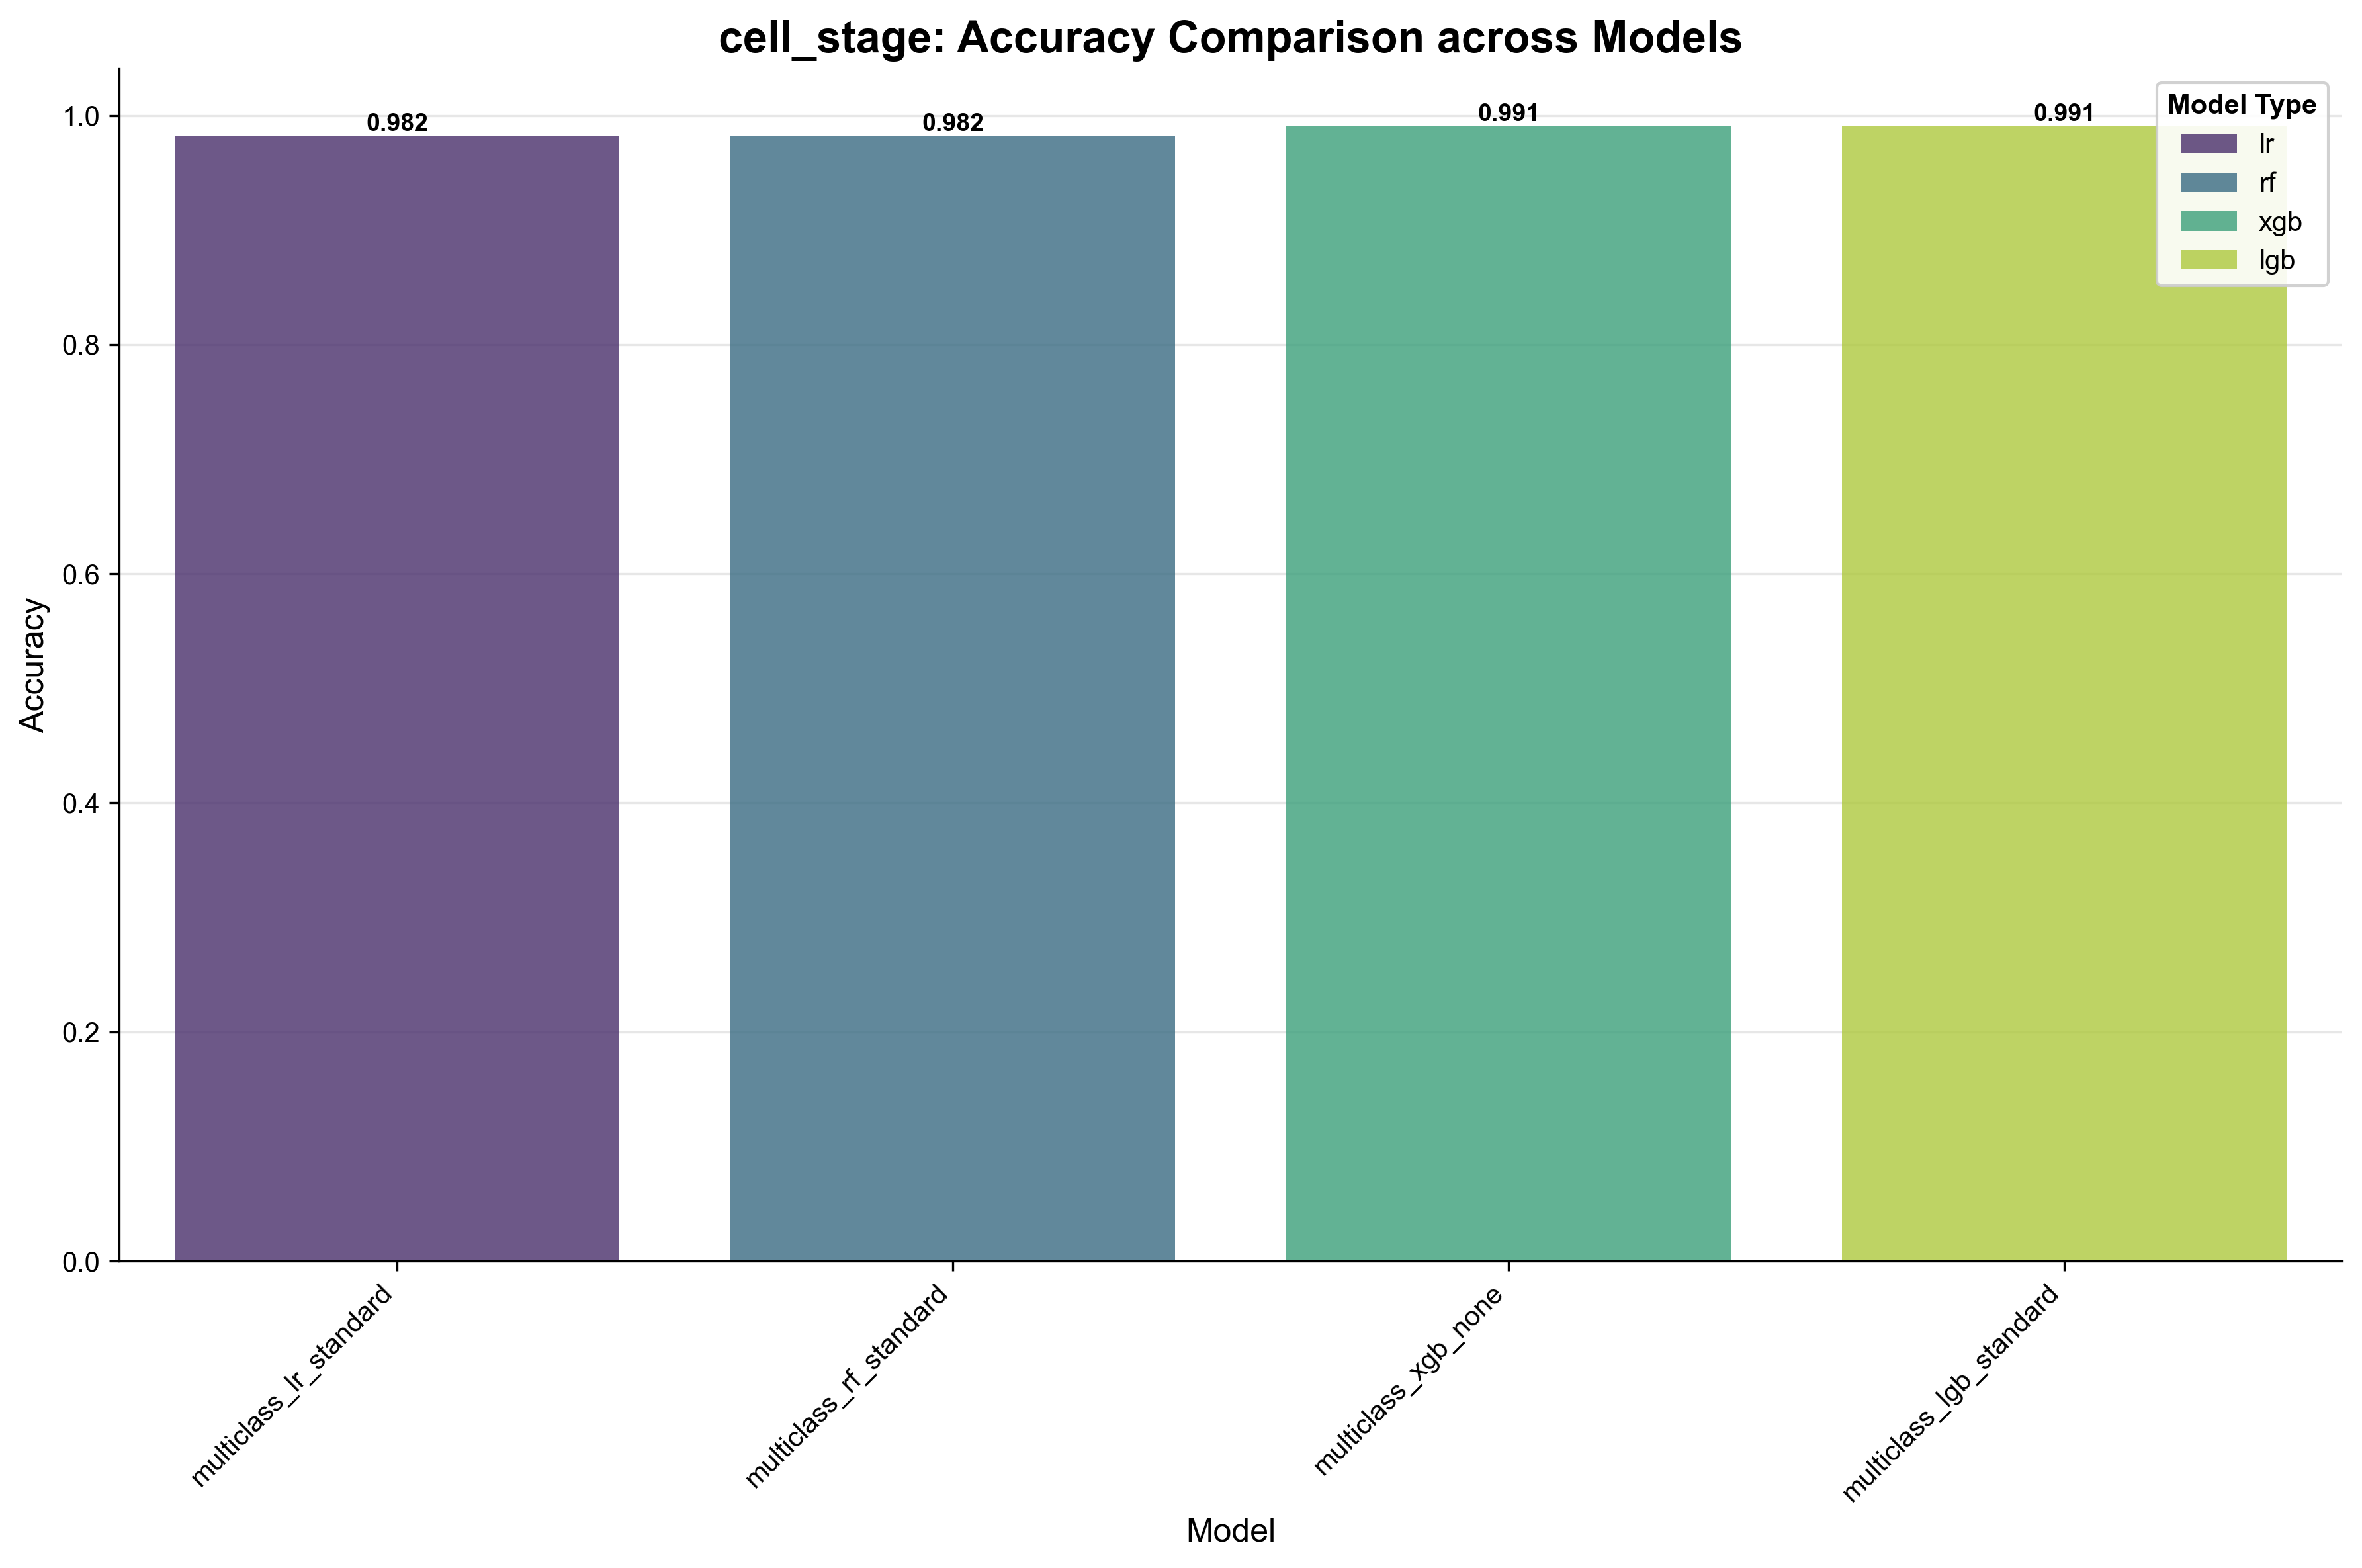

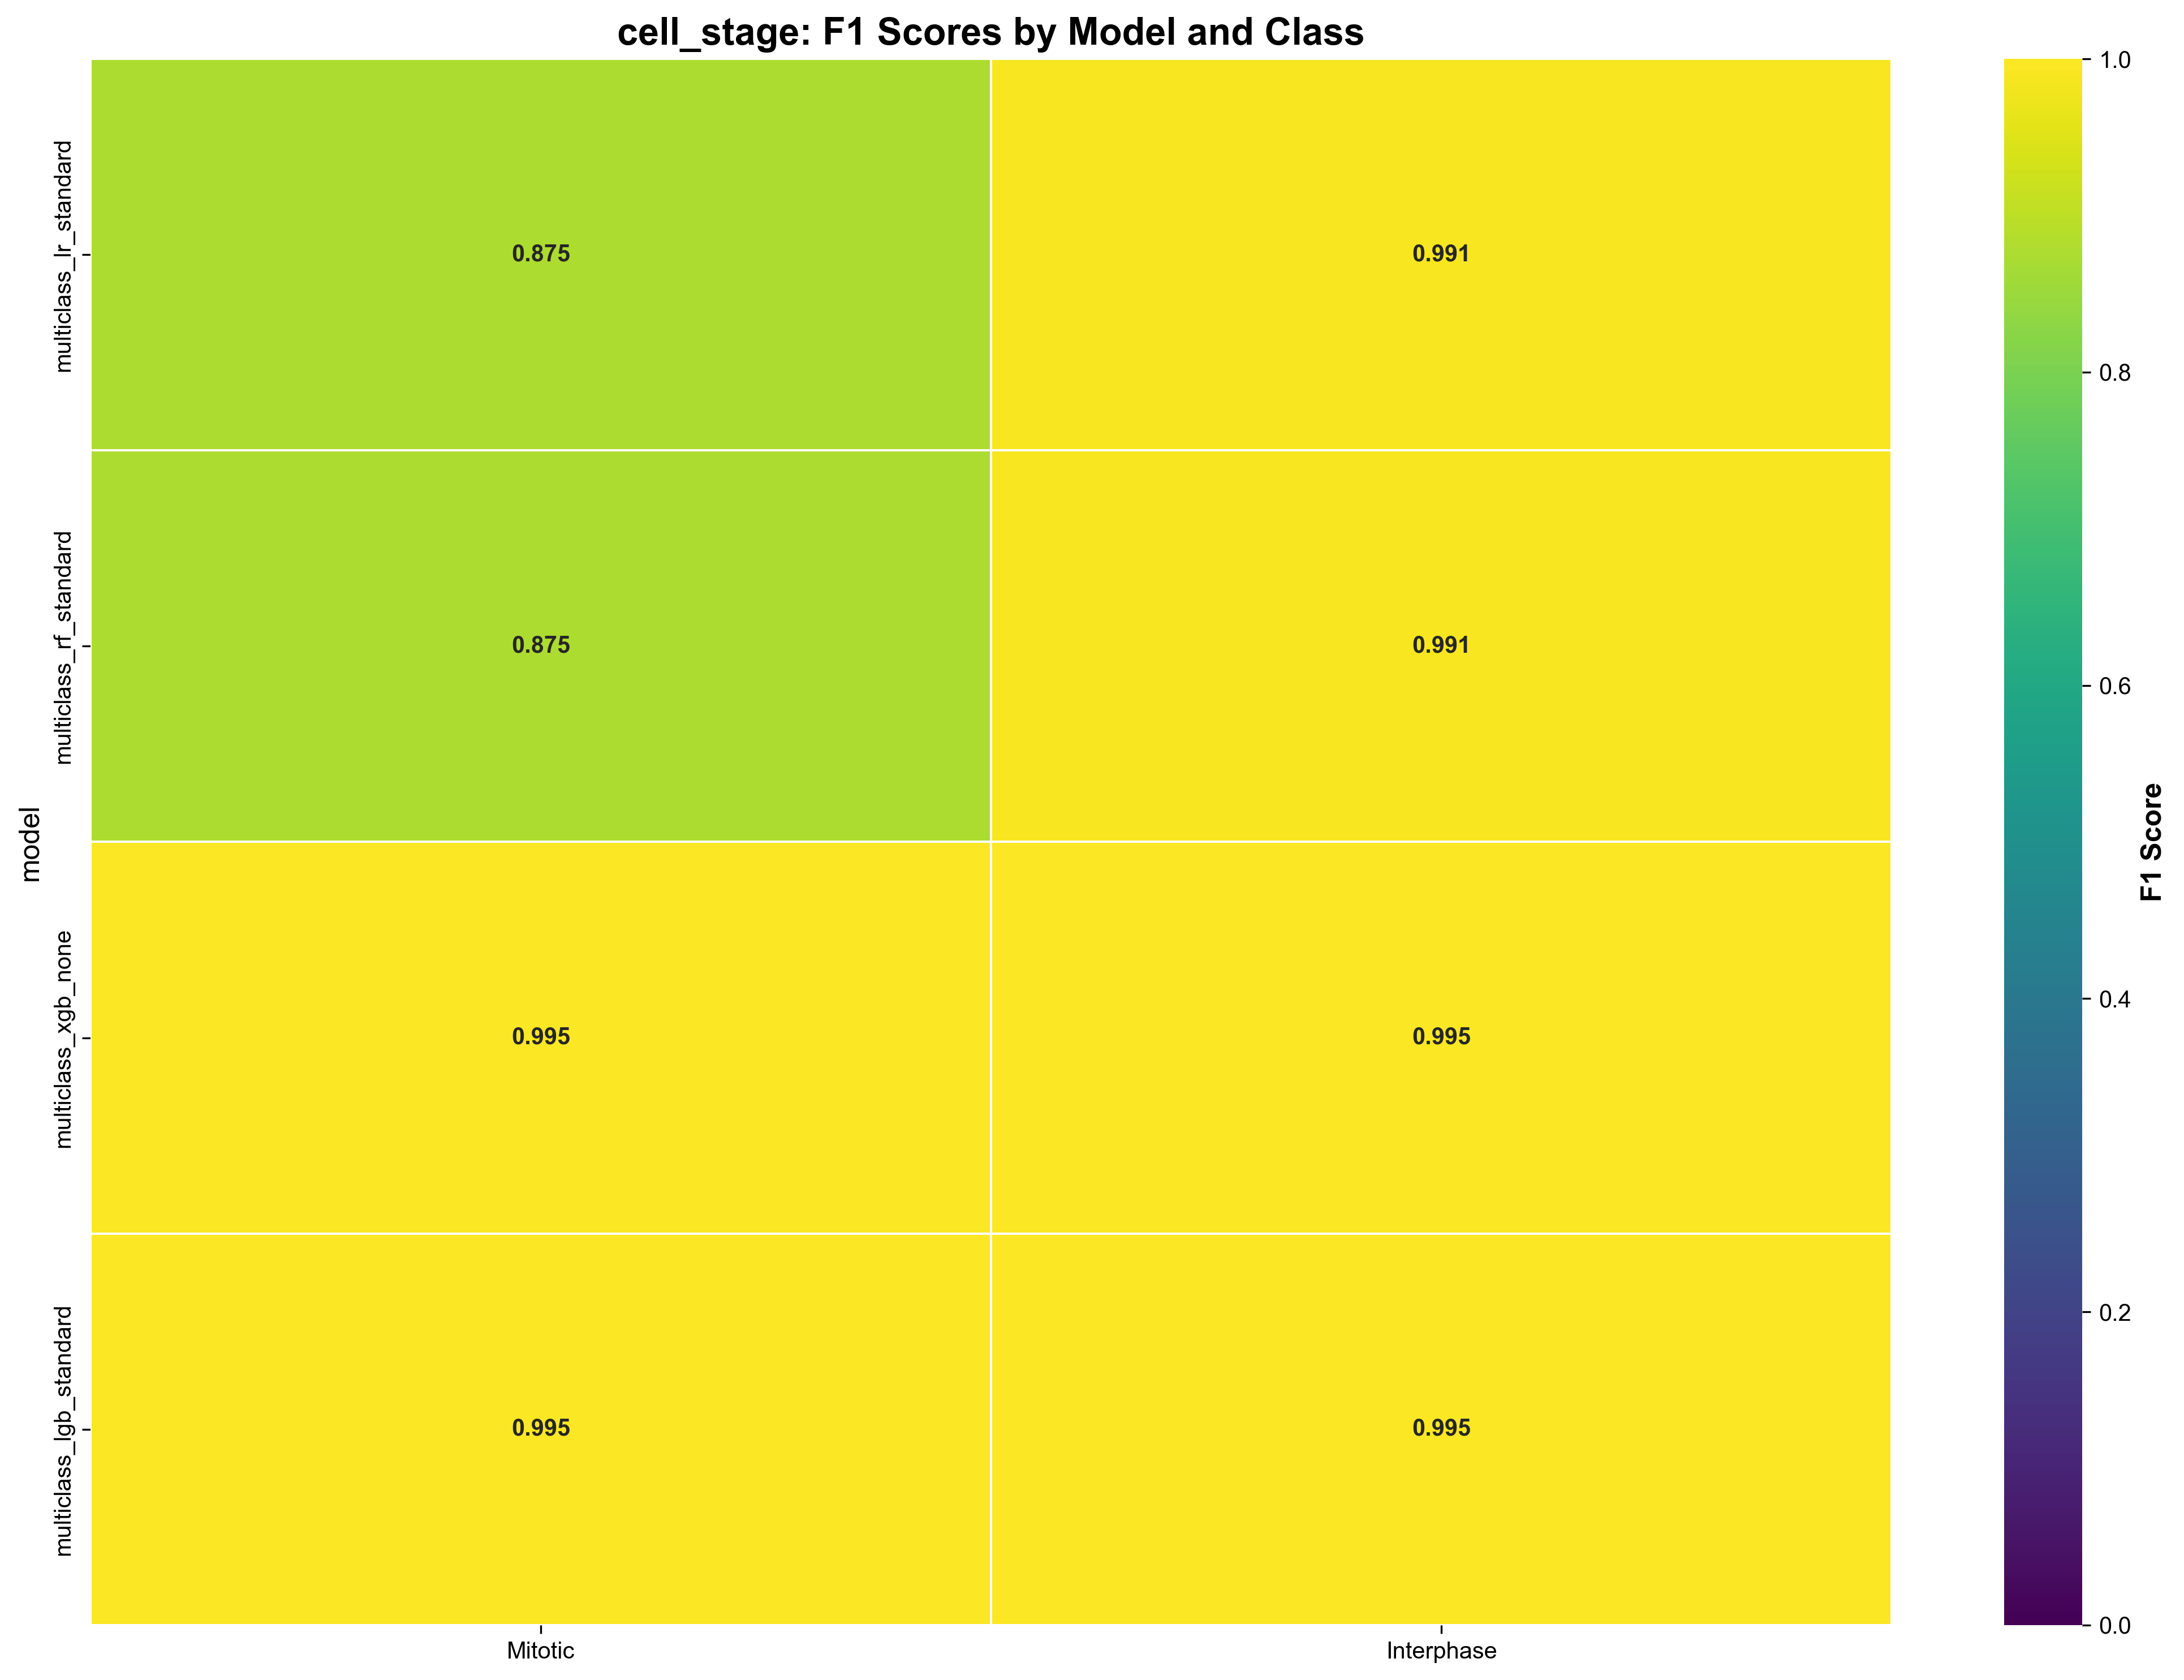

Available models:
multiclass_lr_standard
multiclass_rf_standard
multiclass_xgb_none
multiclass_lgb_standard


In [59]:
_ = display_pngs_in_plots_and_list_models(CLASSIFIER_DIR_PATH)

### 3b. <font color='red'>SET PARAMETERS</font>: Model Settings

- `CLASSIFIER_MODEL`: Name of the model to use (e.g., `"xgb_standard"`). Set to `None` to use the best performing model.
- `COLLAPSE_COLS`: Columns to collapse on when creating classification summaries (e.g., `["plate", "well"]`).

In [60]:
CLASSIFIER_MODEL = "multiclass_xgb_none"
COLLAPSE_COLS = ["plate", "well"]

Selected model: multiclass_xgb_none


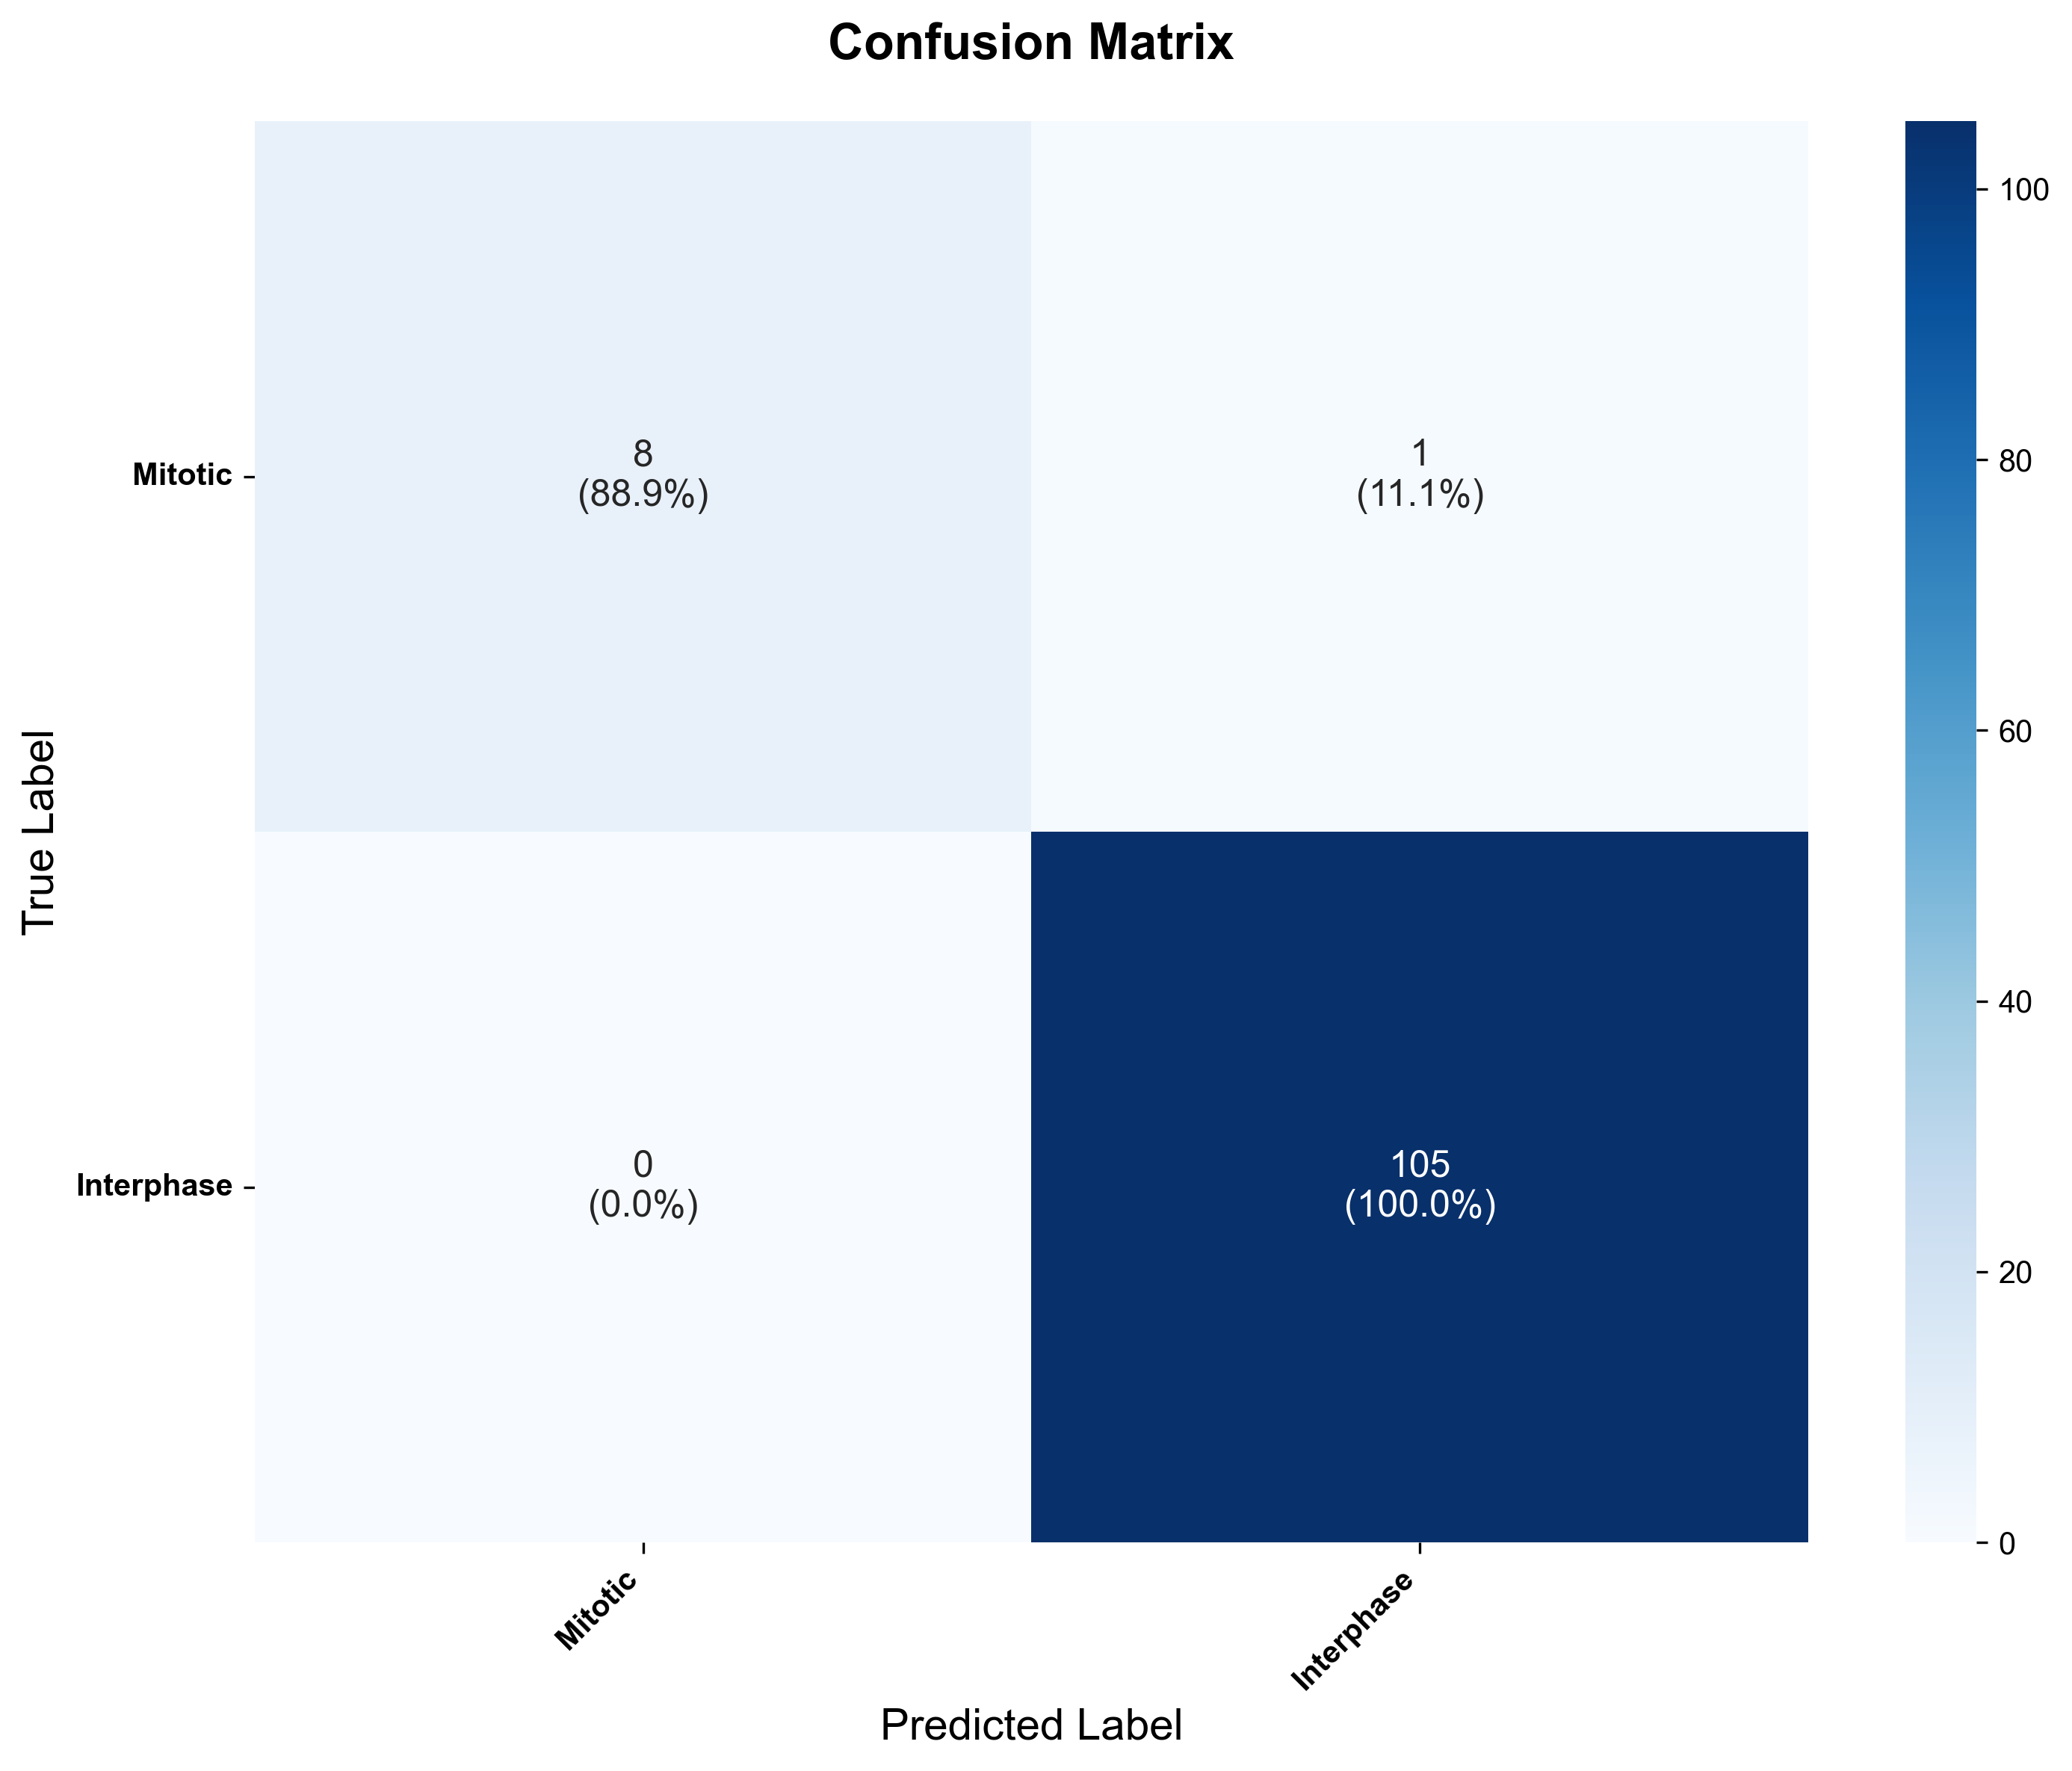

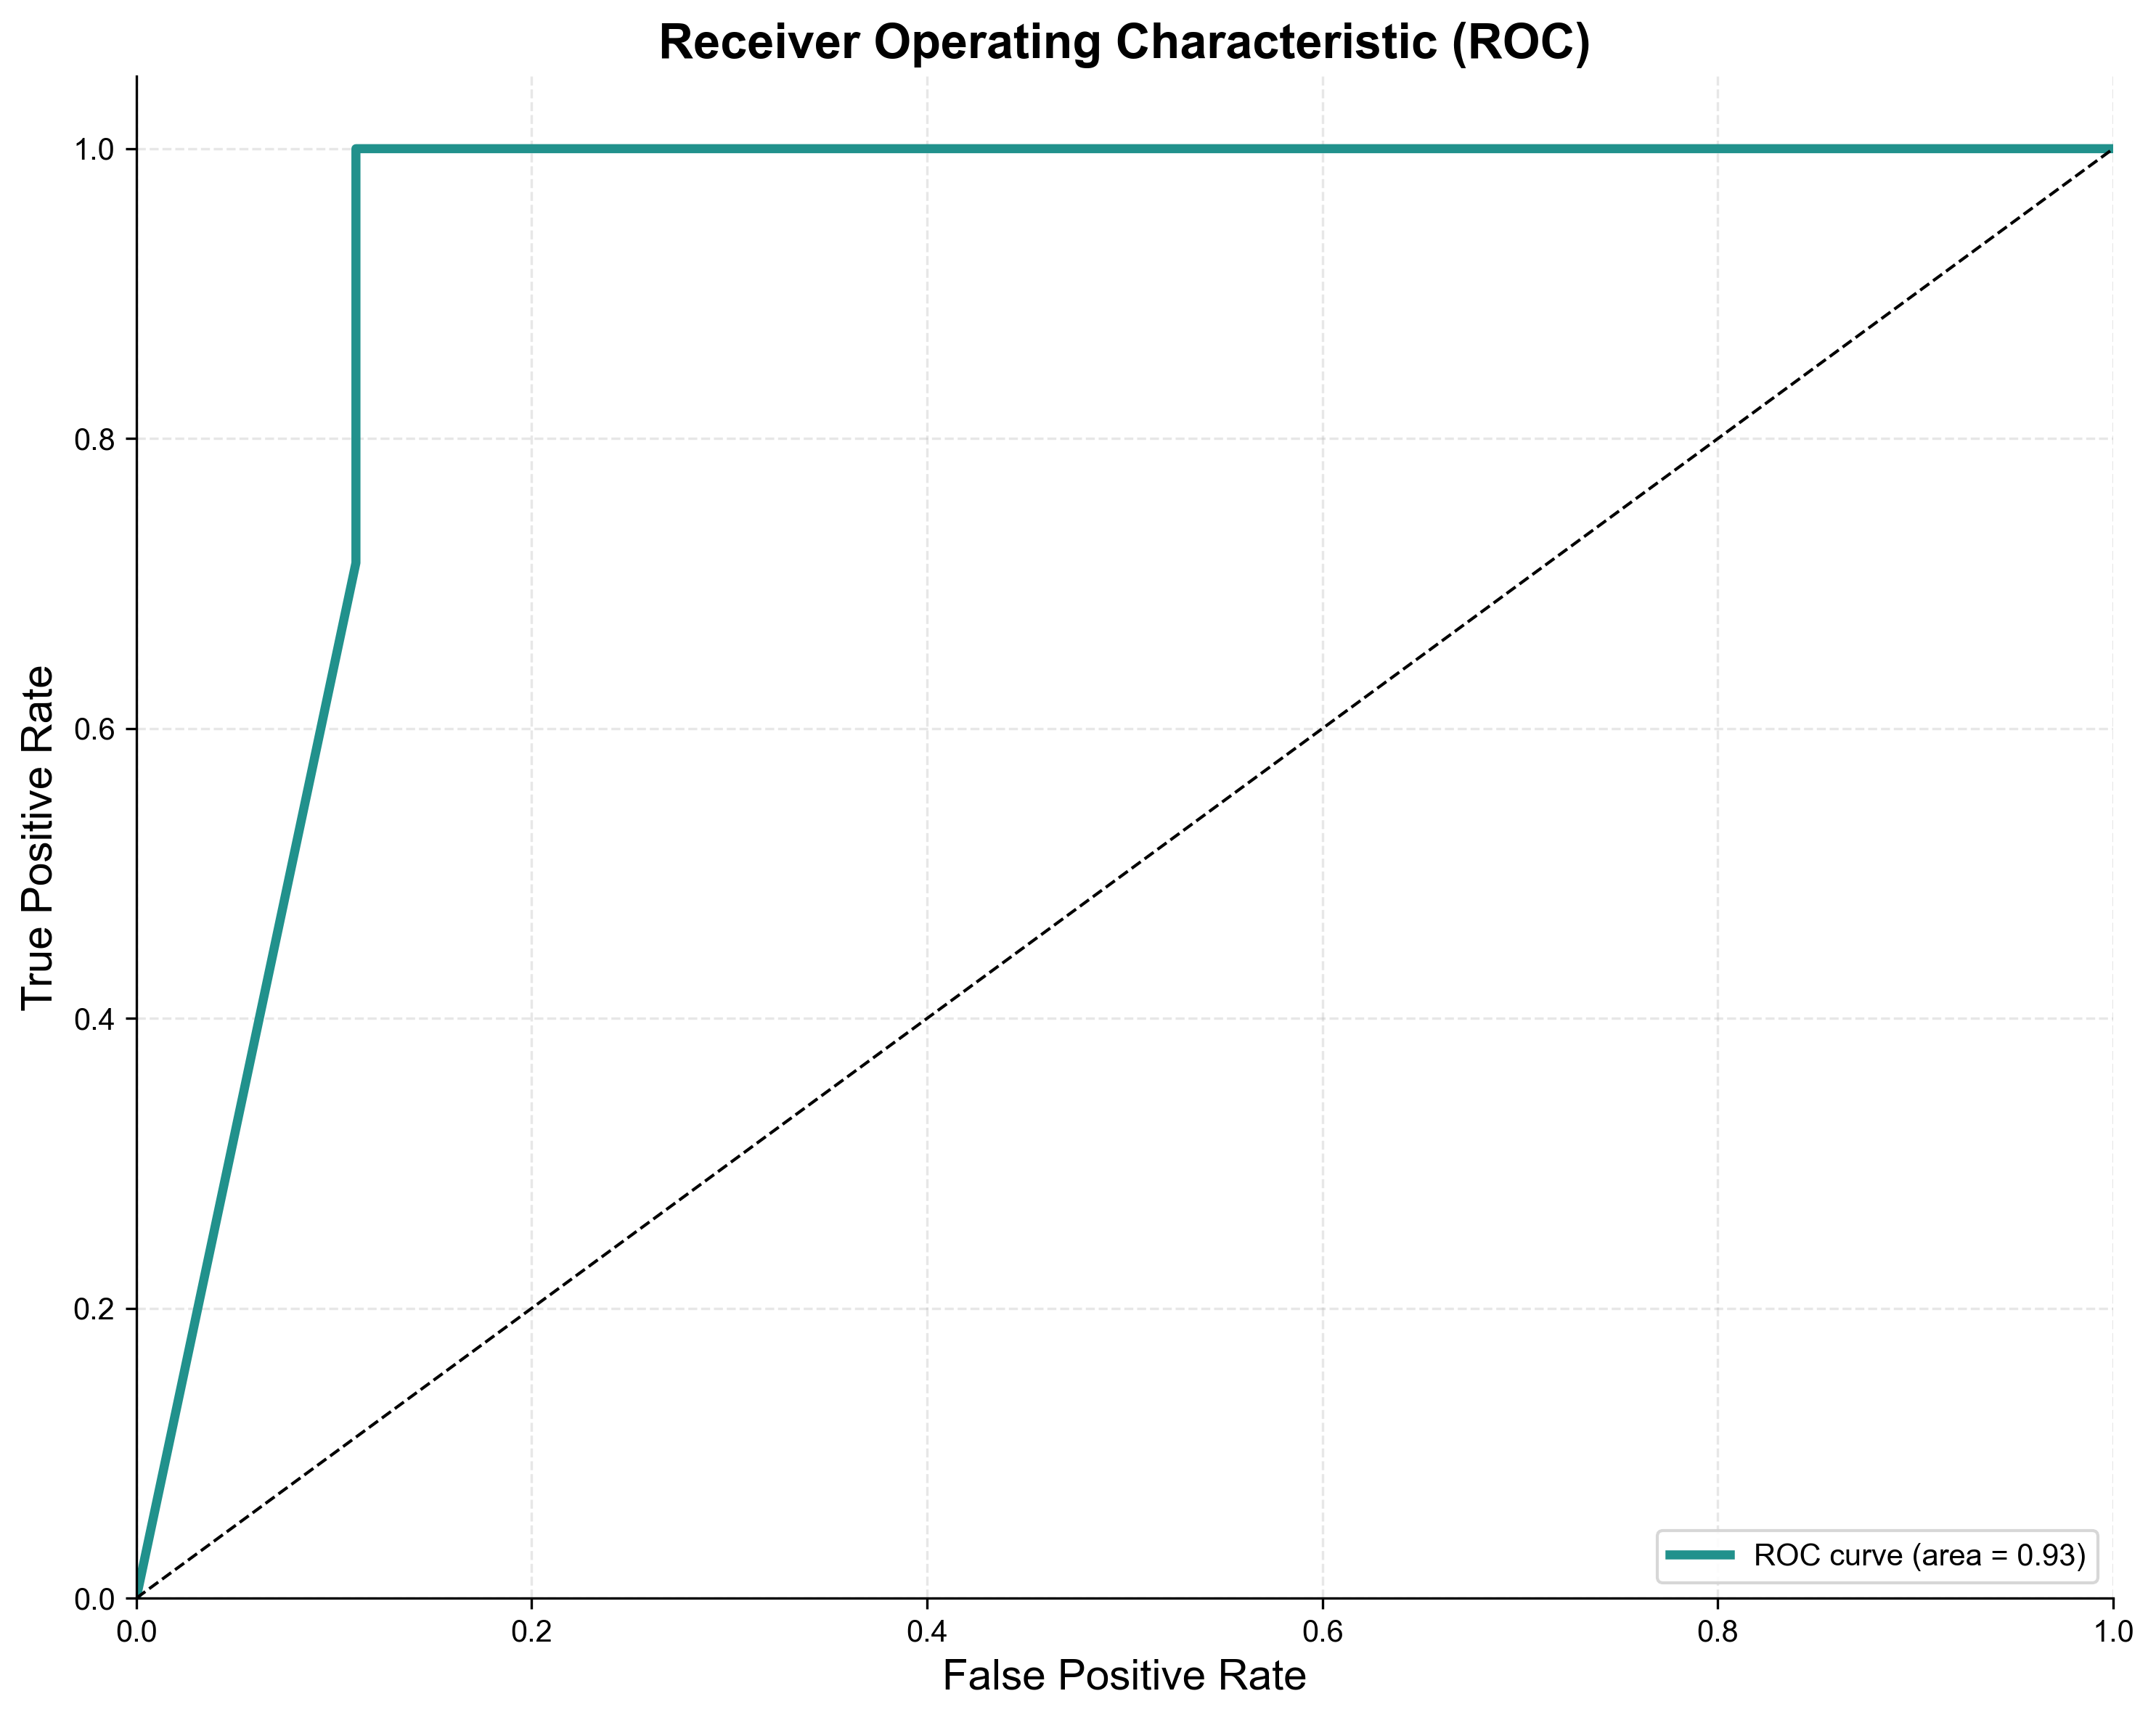

In [61]:
CLASSIFIER_PATH, model_name = resolve_classifier_model_dill_path(CLASSIFIER_DIR_PATH, CLASSIFIER_MODEL)
print("Selected model: " + model_name)
_ = show_model_evaluation_pngs(CLASSIFIER_DIR_PATH, model_name)

Removing 574 rows with NaN values in features
cell_stage
2    1160790
1      15030
Name: count, dtype: int64


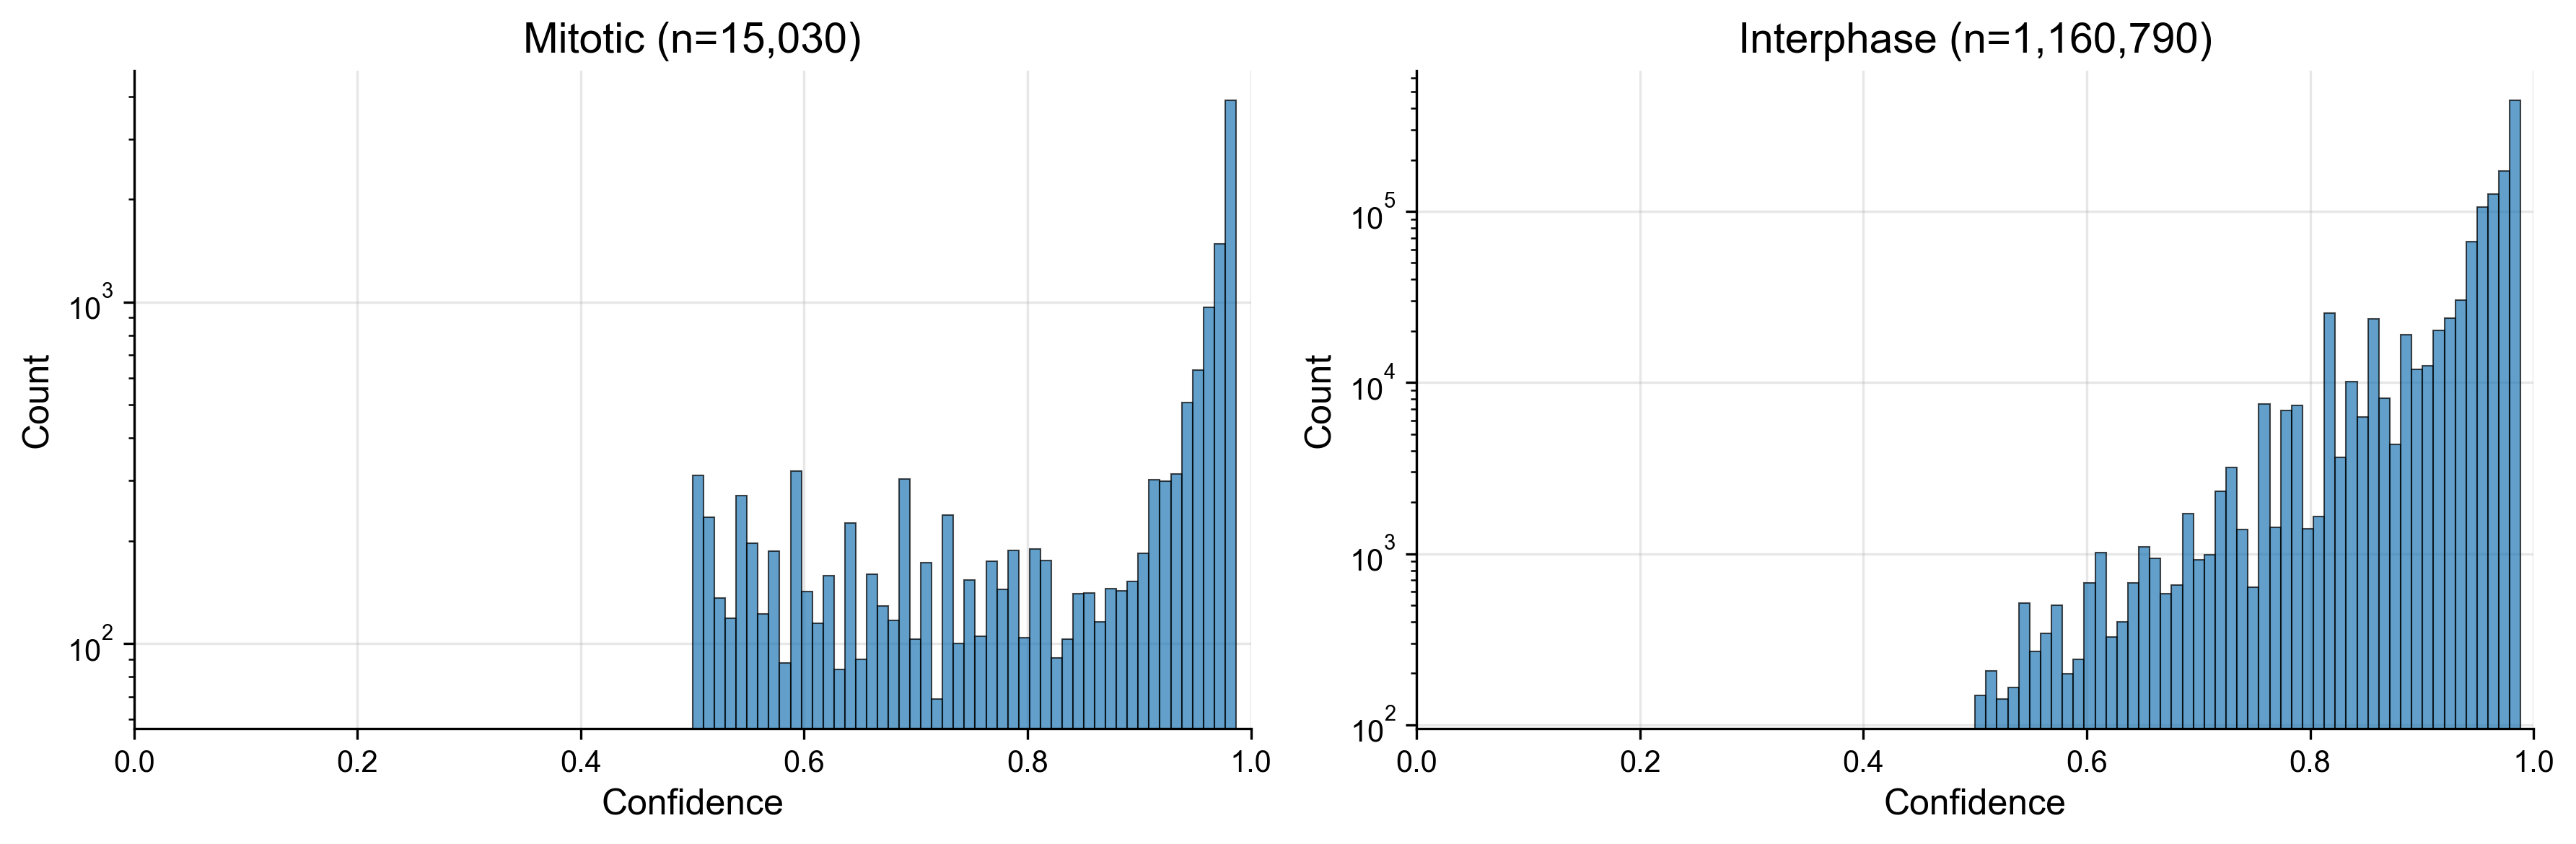

In [62]:
classifier = CellClassifier.load(CLASSIFIER_PATH)
classified_metadata, classified_features = classifier.classify_cells(metadata, features)

print(classified_metadata[CLASS_TITLE].value_counts())

# Plot confidence distribution with log scale for better tail visibility
fig = plot_confidence_distribution(
    classified_metadata=classified_metadata,
    class_title=CLASS_TITLE,
    class_mapping=class_mapping,
    thresholds=None,  # Will add thresholds after setting them below
    log_scale=True,
    figsize=(12, 4),
)
plt.show()

### 3c. <font color='red'>SET PARAMETERS</font>: Confidence Calibration

> **⚠️ Experimental Feature**: Confidence calibration is applied only within this notebook for evaluation and threshold selection. The calibrated confidences are **not** persisted or applied in the downstream aggregate pipeline. Set your thresholds based on raw (uncalibrated) confidence scores if you skip calibration, or be aware that thresholds chosen with calibration enabled may behave differently in production.

When your classifier predicts whether an object belongs to a category, it also gives a confidence score. However, these confidence scores can be inaccurate - the model might say "80% confident" when it's actually only correct 60% of the time.

**When to apply post-hoc correction:**
- First, run with `CONFIDENCE_CORRECTION = None` and examine the confidence histogram and rankline UI below
- If high-confidence predictions seem frequently wrong, or the confidence scores don't match reality, enable calibration
- If your confidence scores already look reliable, you can skip calibration

**Set parameters:**
- `CONFIDENCE_CORRECTION`: Set to `"post-hoc"` to enable correction. Defaults to `None` (skip correction).
- `CALIBRATION_DATASET_FP`: Path to additional calibration dataset (only used if correction enabled). Set to `None` to use the training dataset.
- `CALIBRATION_METHOD`: Calibration method to use. Options are `"isotonic"` (recommended, works for most cases) or `"sigmoid"` (best for very small datasets < 100 objects).

**Recommended workflow:**
1. Start with `CONFIDENCE_CORRECTION = None`
2. Run the cells below and examine the confidence distribution
3. Use the rankline UI to manually check if high-confidence predictions match your expectations
4. If confidence scores seem unreliable, come back and set `CONFIDENCE_CORRECTION = "post-hoc"` with `CALIBRATION_METHOD = "isotonic"`

In [63]:
CONFIDENCE_CORRECTION = None
CALIBRATION_DATASET_FP = None
CALIBRATION_METHOD = "isotonic"

In [64]:
if CONFIDENCE_CORRECTION is None:
    print("Skipping confidence calibration")
else:
    if CALIBRATION_DATASET_FP is not None:
        manual_labeled_data = load_cellprofiler_data([CALIBRATION_DATASET_FP])
    else:
        # Use training dataset for calibration
        if TRAINING_DATASET_FP is None:
            raise ValueError(
                "Set CALIBRATION_DATASET_FP or TRAINING_DATASET_FP for calibration"
            )
        print(f"No calibration dataset provided, using training dataset: {TRAINING_DATASET_FP}")
        manual_labeled_data = load_cellprofiler_data([TRAINING_DATASET_FP])

    classified_metadata, meta = calibrate_confidence(
        master_phenotype_df=master_phenotype_df,
        classified_metadata=classified_metadata,
        manual_labeled_data=manual_labeled_data,
        classify_by=MODE,
        class_title=CLASS_TITLE,
        classifier_path=CLASSIFIER_PATH,
        confidence_correction=CONFIDENCE_CORRECTION,
        calibration_method=CALIBRATION_METHOD,
        test_plate=plates,
        test_well=wells,
        min_samples_isotonic=50,
        verbose=True,
    )

Skipping confidence calibration


In [65]:
summary_df, ORDERED_CLASSES = summarize_classification(
    classified_metadata=classified_metadata,
    class_mapping=class_mapping,
    class_title=CLASS_TITLE,
    collapse_cols=COLLAPSE_COLS,
    display_fn=display,
)

,Stage,Count,Percent
0,Raw Data,1175820,100.00
1,Mitotic cells,15030,1.28
2,Mitotic plate,1,0.00
3,Mitotic well,1,0.00
4,Interphase cells,1160790,98.72
5,Interphase plate,1,0.00
6,Interphase well,1,0.00


### 3d. <font color='red'>SET PARAMETERS</font>: Rankline UI Settings

- `MINIMUM_DIFFERENCE`: Minimum confidence difference for comparison.

In [66]:
MINIMUM_DIFFERENCE = 0.001

In [67]:
w = launch_rankline_ui(
    classified_metadata=classified_metadata,
    class_title=CLASS_TITLE,
    classify_by=MODE,
    class_mapping=class_mapping,
    data_source=data_source,
    images_source=ROOT_FP / "phenotype",
    channel_names=list(config["phenotype"]["channel_names"]),
    display_channels=DISPLAY_CHANNEL,
    channel_colors=CHANNEL_COLORS,
    test_plate=plates,
    test_well=wells,
    scale_bar_px=SCALE_BAR,
    minimum_difference=MINIMUM_DIFFERENCE,
    thumbnail_px=150,
    auto_display=True,
)

### 3e. <font color='red'>SET PARAMETERS</font>: Per-Class Confidence Thresholds

Configure per-class thresholds with individual modes for each class:

```python
CONFIDENCE_THRESHOLDS = {
    1: {"threshold": 0.94, "mode": "exclude"},   # Class 1: strict, drop low-confidence
    2: {"threshold": 0.50, "mode": "reassign"},  # Class 2: try reassigning first
}
```

**Modes:**
- `"exclude"` - Drops cells below threshold (default)
- `"reassign"` - Attempts to reassign low-confidence cells to another class if they pass that class's threshold; drops if reassignment fails

Higher thresholds = stricter filtering (fewer cells but higher quality). Use `"reassign"` for the majority class to recover borderline cells.

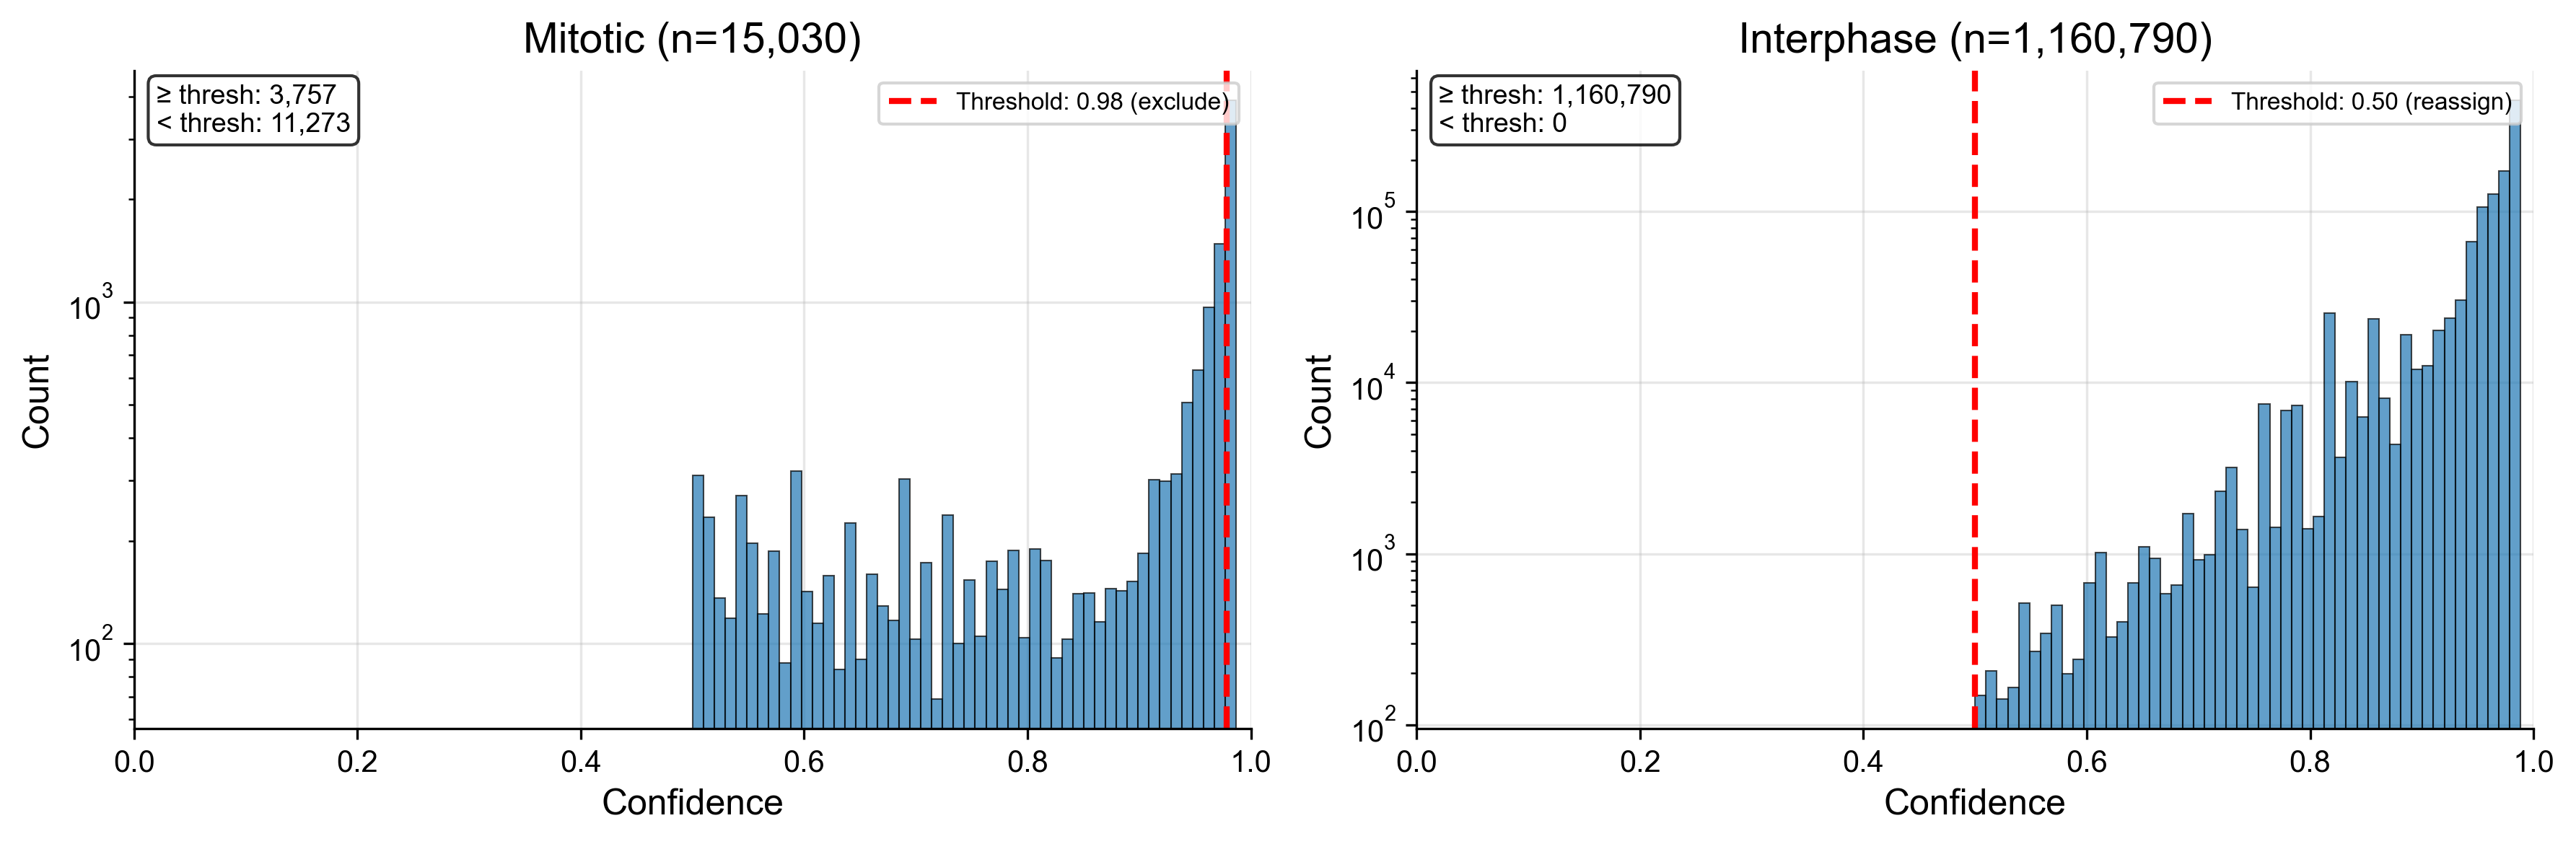


Threshold Summary:


,class_id,class_name,threshold,mode,before,after,dropped,pct_retained
0,1,Mitotic,0.97821,exclude,15030,3757,11273,24.996673
1,2,Interphase,0.5,reassign,1160790,1160790,0,100.000000
2,,TOTAL,,,1175820,1164547,11273,99.041265


In [68]:
# Per-class confidence thresholds with individual modes
# Class IDs correspond to CLASSIFICATION order (1, 2, 3, ...)
CONFIDENCE_THRESHOLDS = {
    1: {"threshold": 0.97821, "mode": "exclude"},
    2: {"threshold": 0.5, "mode": "reassign"},
}

# Visualize confidence distribution with threshold lines
fig = plot_confidence_distribution(
    classified_metadata=classified_metadata,
    class_title=CLASS_TITLE,
    class_mapping=class_mapping,
    thresholds=CONFIDENCE_THRESHOLDS,
    log_scale=True,
    figsize=(12, 4),
)
plt.show()

# Preview what thresholding would do
filtered_df, threshold_summary = apply_class_thresholds(
    classified_metadata=classified_metadata,
    class_title=CLASS_TITLE,
    thresholds=CONFIDENCE_THRESHOLDS,
    class_mapping=class_mapping,
)
print("\nThreshold Summary:")
display(threshold_summary)

In [69]:
config["classify"] = {
    "classifier_path": str(CLASSIFIER_PATH),
    "confidence_thresholds": CONFIDENCE_THRESHOLDS,  # Per-class thresholds dict
    "metadata_cols_fp": str(METADATA_COLS_FP),
    "class_title": CLASS_TITLE,  # Column name for class predictions (e.g., "cell_stage")
    "class_mapping": class_mapping,  # Maps numeric IDs to string labels: {"label_to_class": {1: "Mitotic", 2: "Interphase"}}
}

with open(CONFIG_FILE_PATH, "w") as config_file:
    config_file.write(CONFIG_FILE_HEADER)
    yaml.safe_dump(config, config_file, default_flow_style=False, sort_keys=False)

print("Saved classifier settings to config.")

Saved classifier settings to config.
